# **Streamflow Analysis: Hydrographs, Baseflow Separation, and Flood Frequency**

Reading a 24-year streamflow record from a small Alabama catchment: what the river does day to day, how much of it is groundwater, and how big the rare floods are.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Plot and interpret a daily hydrograph and a flow duration curve.
- Separate baseflow from quickflow with a recursive digital filter and compute the baseflow index.
- Compute the annual runoff ratio from streamflow and catchment precipitation.
- Fit Gumbel and log-normal distributions to annual peak flows and estimate the 10-, 50-, and 100-year floods.

**Before you start:** Uses `scipy.stats`. The data were downloaded from USGS Water Services and Daymet and are bundled in `sample_data/`.

## **The catchment**

**USGS 02423130, Cahaba River at Trussville, Alabama.** Drainage area 19.7 mi$^2$ (51.0 km$^2$), a small headwater
catchment northeast of Birmingham in the Valley and Ridge province. Humid subtropical climate, about 1,400 mm of rain
per year with winter and spring peaks. Daily mean discharge for 2000-2023 is in `usgs_02423130_Cahaba_daily_discharge_2000_2023.csv`
and Daymet daily precipitation for the gauge location in `daymet_Cahaba_02423130_2000_2023.csv`.

## **Baseflow separation with a digital filter**

Streamflow has a slow component (baseflow, mostly groundwater) and a fast component (quickflow, from storm runoff).
The Lyne-Hollick (1979) recursive filter separates them:

$$ q_{f}(t) = a \, q_{f}(t-1) + \frac{1 + a}{2}\left[Q(t) - Q(t-1)\right], \qquad q_b = Q - q_f \qquad (1) $$

with filter parameter $a = 0.925$ and the constraint $0 \le q_b \le Q$. The filter is passed forward, backward, and forward
again (three passes). The **baseflow index** $BFI = \sum q_b / \sum Q$ tells you how much of the river is groundwater.

## **Flood frequency**

Take the largest daily flow in each water year (the *annual maximum series*), fit a probability distribution, and read
off the flow with a given return period $T$ (exceeded on average once every $T$ years, i.e., with annual probability $1/T$).
The **Gumbel** distribution is the classic choice:

$$ Q_T = \mu - \sigma_g \ln\!\left[-\ln\!\left(1 - \frac{1}{T}\right)\right] \qquad (2) $$

Real design work uses log-Pearson III with regional skew (USGS Bulletin 17C). Here we compare Gumbel and log-normal to see
how much the choice matters.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['usgs_02423130_Cahaba_daily_discharge_2000_2023.csv', 'daymet_Cahaba_02423130_2000_2023.csv']
paths = {f: get_data(f) for f in files}
paths

{'usgs_02423130_Cahaba_daily_discharge_2000_2023.csv': '..\\..\\sample_data\\usgs_02423130_Cahaba_daily_discharge_2000_2023.csv',
 'daymet_Cahaba_02423130_2000_2023.csv': '..\\..\\sample_data\\daymet_Cahaba_02423130_2000_2023.csv'}

In [2]:
q = pd.read_csv(paths['usgs_02423130_Cahaba_daily_discharge_2000_2023.csv'], parse_dates=['Date']).set_index('Date')
pr = pd.read_csv(paths['daymet_Cahaba_02423130_2000_2023.csv'], parse_dates=['Date']).set_index('Date')
area_km2 = 51.0
q['Q_mm'] = q['Q_m3s'] * 86400 / (area_km2 * 1e6) * 1000        # discharge as depth over the catchment, mm/day
d = q.join(pr['P_mm'])
print(d.describe().round(2))

         Q_cfs    Q_m3s     Q_mm     P_mm
count  8766.00  8766.00  8766.00  8760.00
mean     34.92     0.99     1.68     4.49
std      97.24     2.75     4.66    11.11
min       0.00     0.00     0.00     0.00
25%       2.20     0.06     0.11     0.00
50%      10.90     0.31     0.52     0.00
75%      30.30     0.86     1.45     3.57
max    2160.00    61.16   103.62   177.45


## **Step 1: The hydrograph and the flow duration curve**

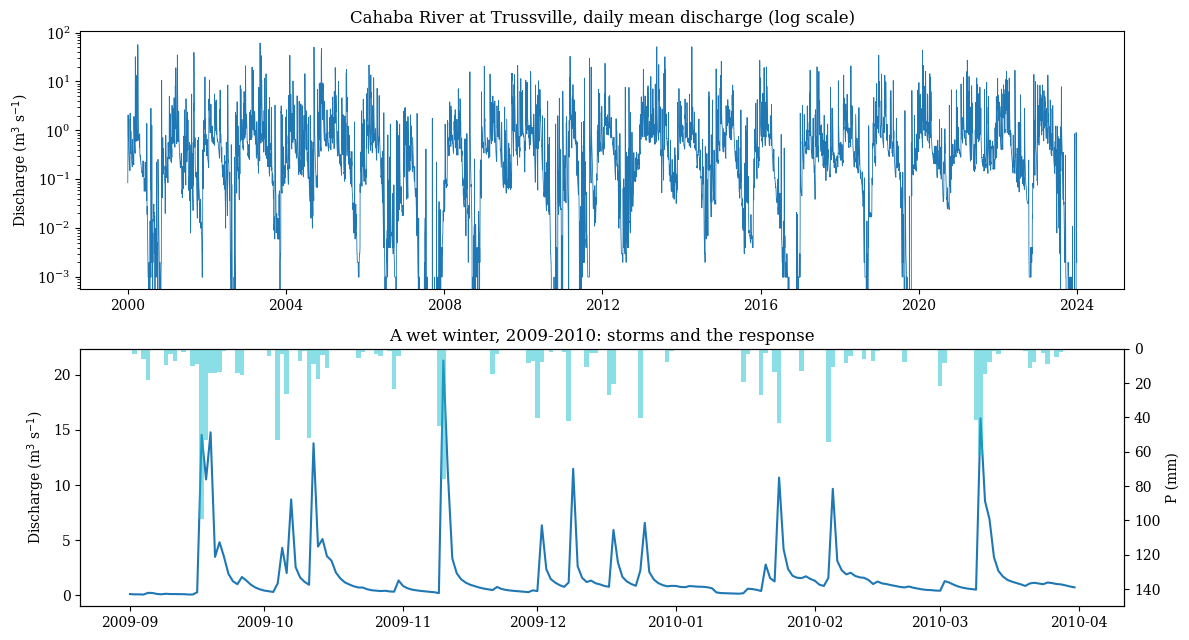

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6.5))
axs[0].plot(d.index, d['Q_m3s'], lw=0.6, color='tab:blue'); axs[0].set_yscale('log'); axs[0].set_ylabel('Discharge (m$^3$ s$^{-1}$)')
axs[0].set_title('Cahaba River at Trussville, daily mean discharge (log scale)')
sl = d.loc['2009-09':'2010-03']
axs[1].plot(sl.index, sl['Q_m3s'], color='tab:blue', label='Discharge'); axs[1].set_ylabel('Discharge (m$^3$ s$^{-1}$)')
ax2 = axs[1].twinx(); ax2.bar(sl.index, sl['P_mm'], color='tab:cyan', alpha=0.5, width=1, label='Precipitation'); ax2.set_ylim(0, 150); ax2.invert_yaxis(); ax2.set_ylabel('P (mm)')
axs[1].set_title('A wet winter, 2009-2010: storms and the response'); plt.tight_layout()

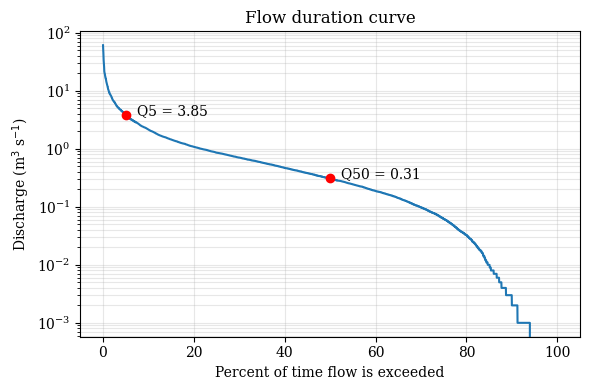

In [4]:
flows = d['Q_m3s'].dropna().sort_values(ascending=False).values
exceed = np.arange(1, len(flows) + 1) / (len(flows) + 1) * 100
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(exceed, flows); ax.set_xlabel('Percent of time flow is exceeded'); ax.set_ylabel('Discharge (m$^3$ s$^{-1}$)')
for p_ in [5, 50, 95]:
    v = np.percentile(d['Q_m3s'].dropna(), 100 - p_); ax.plot(p_, v, 'ro'); ax.annotate(f'Q{p_} = {v:.2f}', (p_, v), textcoords='offset points', xytext=(8, 0))
ax.set_title('Flow duration curve'); ax.grid(True, which='both', alpha=0.3); plt.tight_layout()

The flow duration curve is steep: the river spends most of its time at low flow and a few days at flows fifty times
higher. The ratio Q5/Q95 is a measure of flashiness. Small catchments with thin soils and steep slopes are flashy;
large catchments with deep aquifers are not.

## **Step 2: Baseflow separation**

Baseflow index (2000-2023) = 0.23


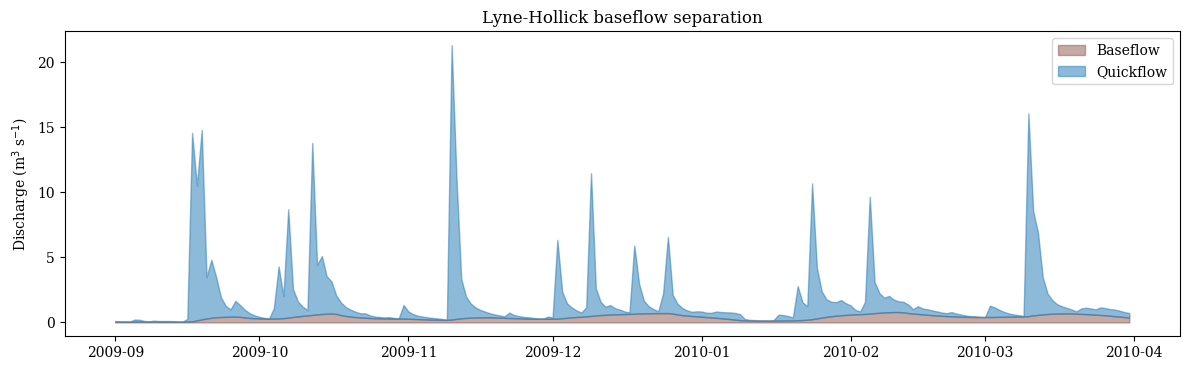

In [5]:
def lyne_hollick(Q, a=0.925, passes=3):
    Q = np.asarray(Q, float); qb = Q.copy()
    for p_ in range(passes):
        qf = np.zeros_like(Q); src = qb
        rng = range(1, len(Q)) if p_ % 2 == 0 else range(len(Q) - 2, -1, -1)
        prev = 0 if p_ % 2 == 0 else len(Q) - 1
        for t in rng:
            qf[t] = a * qf[prev] + (1 + a) / 2 * (src[t] - src[prev])
            qf[t] = min(max(qf[t], 0), src[t])
            prev = t
        qb = src - qf
    return qb

d['Qb'] = lyne_hollick(d['Q_m3s'].interpolate().values)
bfi = d['Qb'].sum() / d['Q_m3s'].sum()
print(f'Baseflow index (2000-2023) = {bfi:.2f}')
sl = d.loc['2009-09':'2010-03']
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.fill_between(sl.index, 0, sl['Qb'], color='tab:brown', alpha=0.5, label='Baseflow'); ax.fill_between(sl.index, sl['Qb'], sl['Q_m3s'], color='tab:blue', alpha=0.5, label='Quickflow')
ax.set_ylabel('Discharge (m$^3$ s$^{-1}$)'); ax.legend(); ax.set_title('Lyne-Hollick baseflow separation'); plt.tight_layout()

## **Step 3: Annual water balance and runoff ratio**

         P_mm     Q_mm   Qb_mm  runoff ratio  ET_residual
Date                                                     
2001  1925.50   632.30   95.57          0.33      1293.20
2002  1649.65   456.81  126.79          0.28      1192.84
2003  2025.74  1083.98  206.17          0.54       941.76
2004  1511.11   623.10   99.26          0.41       888.01
2005  1690.89  1125.30  225.69          0.67       565.59
2006  1392.79   484.15   90.79          0.35       908.64
2007   950.98   128.49   21.59          0.14       822.49
2008  1428.35   299.64   84.40          0.21      1128.71
2009  1901.44   548.66  140.16          0.29      1352.78
2010  1761.39   800.92  181.10          0.45       960.47
2011  1669.90   518.22   67.47          0.31      1151.68
2012  1524.86   425.71  138.53          0.28      1099.15
2013  1908.53  1003.32  253.32          0.53       905.21
2014  1478.46   463.99  156.25          0.31      1014.47
2015  1690.54   599.06  165.63          0.35      1091.48
2016  1444.43 

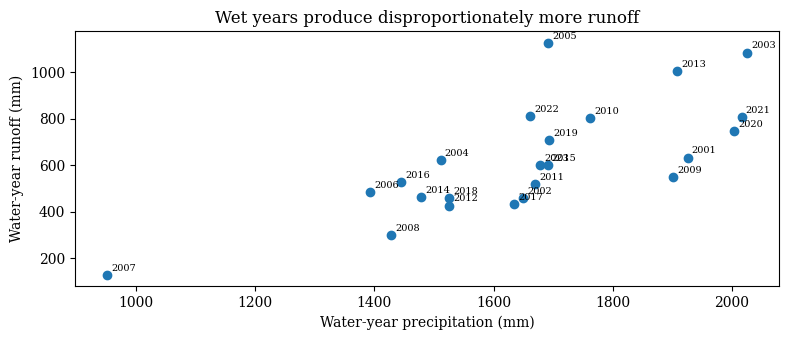

In [6]:
wy = d.index.year + (d.index.month >= 10)                    # water year (Oct-Sep)
ann = d.groupby(wy)[['P_mm', 'Q_mm']].sum()
ann['Qb_mm'] = d.groupby(wy).apply(lambda g: (g['Qb'] * 86400 / (area_km2 * 1e6) * 1000).sum())
ann = ann.loc[2001:2023]                                     # complete water years only
ann['runoff ratio'] = ann['Q_mm'] / ann['P_mm']; ann['ET_residual'] = ann['P_mm'] - ann['Q_mm']
print(ann.round(2))
print(f"\nMean runoff ratio = {ann['runoff ratio'].mean():.2f}; mean water-balance ET = {ann['ET_residual'].mean():.0f} mm")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(ann['P_mm'], ann['Q_mm']); [ax.annotate(str(y), (x, v), fontsize=7, textcoords='offset points', xytext=(3, 3)) for y, x, v in zip(ann.index, ann['P_mm'], ann['Q_mm'])]
ax.set_xlabel('Water-year precipitation (mm)'); ax.set_ylabel('Water-year runoff (mm)'); ax.set_title('Wet years produce disproportionately more runoff'); plt.tight_layout()

The residual $P - Q$ is an estimate of catchment evapotranspiration, assuming storage changes and deep groundwater
losses are small over a year. Compare it with the site-scale ET you computed for Vaira Ranch in Notebooks 01 and 02:
this humid catchment evaporates far more water, and yet its runoff ratio is still only about a third.

## **Step 4: Flood frequency**

                    Gumbel (m3/s)  Log-normal (m3/s)
Return period (yr)                                  
2                            27.2               25.2
5                            40.6               43.3
10                           49.5               57.4
25                           60.7               77.5
50                           69.0               94.1
100                          77.3              112.1


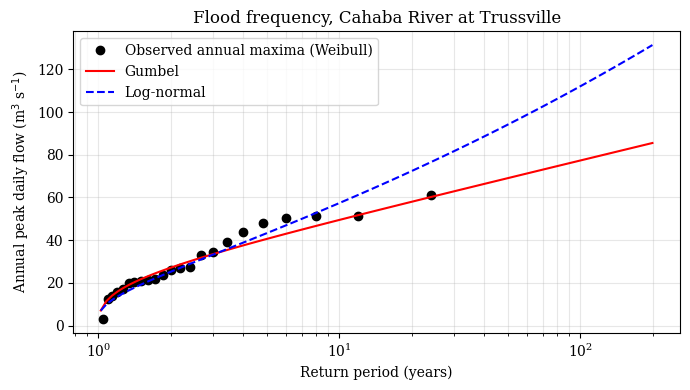

In [7]:
peaks = d.groupby(wy)['Q_m3s'].max().loc[2001:2023]          # annual maximum series (daily means; instantaneous peaks are higher)
n = len(peaks); ranked = np.sort(peaks.values)[::-1]
T_emp = (n + 1) / np.arange(1, n + 1)                        # Weibull plotting position
T = np.array([2, 5, 10, 25, 50, 100])
# Gumbel (method of moments)
mu = peaks.mean() - 0.5772 * peaks.std() * np.sqrt(6) / np.pi; sg = peaks.std() * np.sqrt(6) / np.pi
Q_gumbel = mu - sg * np.log(-np.log(1 - 1 / T))
# Log-normal (MLE on log flows)
s_ln, loc_ln, scale_ln = stats.lognorm.fit(peaks.values, floc=0)
Q_ln = stats.lognorm.ppf(1 - 1 / T, s_ln, loc_ln, scale_ln)
tab = pd.DataFrame({'Return period (yr)': T, 'Gumbel (m3/s)': Q_gumbel.round(1), 'Log-normal (m3/s)': Q_ln.round(1)}).set_index('Return period (yr)')
print(tab)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(T_emp, ranked, 'ko', label='Observed annual maxima (Weibull)')
Tt = np.logspace(0.01, 2.3, 100)
ax.semilogx(Tt, mu - sg * np.log(-np.log(1 - 1 / Tt)), 'r-', label='Gumbel'); ax.semilogx(Tt, stats.lognorm.ppf(1 - 1 / Tt, s_ln, loc_ln, scale_ln), 'b--', label='Log-normal')
ax.set_xlabel('Return period (years)'); ax.set_ylabel('Annual peak daily flow (m$^3$ s$^{-1}$)'); ax.legend(); ax.grid(True, which='both', alpha=0.3)
ax.set_title('Flood frequency, Cahaba River at Trussville'); plt.tight_layout()

**What to notice.** Both distributions fit the common floods; they diverge for the rare ones, exactly where the estimates
matter and where 23 years of data cannot settle the question. Two cautions: (1) these are daily mean flows, so the
instantaneous peaks that matter for bridge design are higher; (2) a short record makes the 100-year estimate very
uncertain, which is why design practice uses regional information and Bulletin 17C procedures.

## **Exercises**

**Exercise 1.** Change the filter parameter $a$ to 0.90 and 0.95. How sensitive is the baseflow index? Why must the filter be run in both directions?

**Exercise 2.** Compute the recession constant: select periods of at least 10 days without rain and fit $Q(t) = Q_0 e^{-t/\tau}$. What is $\tau$ in days, and what does it say about the catchment's storage?

**Exercise 3.** Bootstrap the annual maximum series (resample with replacement 1000 times) and compute a 90% confidence interval for the 100-year flood. Report the width relative to the estimate.

**Exercise 4.** Compute the runoff ratio for each season (winter, spring, summer, fall). When is it lowest, and what does that tell you about evapotranspiration in this catchment?

## **References**

- Lyne, V., & Hollick, M. (1979). Stochastic time-variable rainfall-runoff modelling. *Institute of Engineers Australia National Conference*, 89-93.
- Nathan, R. J., & McMahon, T. A. (1990). Evaluation of automated techniques for base flow and recession analyses. *Water Resources Research*, 26, 1465-1473.
- England, J. F., et al. (2019). *Guidelines for determining flood flow frequency, Bulletin 17C.* USGS Techniques and Methods 4-B5.
- Dingman, S. L. (2015). *Physical Hydrology*, 3rd ed., Chapters 9-10.